<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [18]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#### Step 1: Load the dataset


In [4]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




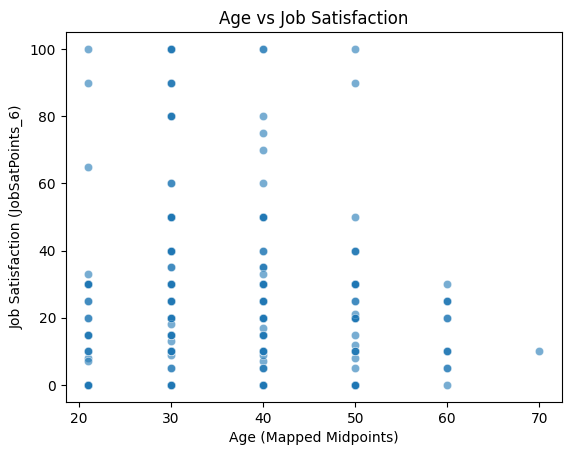

In [22]:
## Write your code here
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df['Age_mapped'] = df['Age'].map(age_map)

clean_df = df[['Age_mapped', 'JobSatPoints_6']].dropna().head(300)

sns.scatterplot(
    x='Age_mapped',
    y='JobSatPoints_6',
    data=clean_df,
    alpha=0.6
)

plt.xlabel('Age (Mapped Midpoints)')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')
plt.title('Age vs Job Satisfaction')
plt.show()

##The scatter plot indicates a weak negative relationship between age and job satisfaction,
##with high variability across all age groups, suggesting that age alone does not strongly influence job satisfaction

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


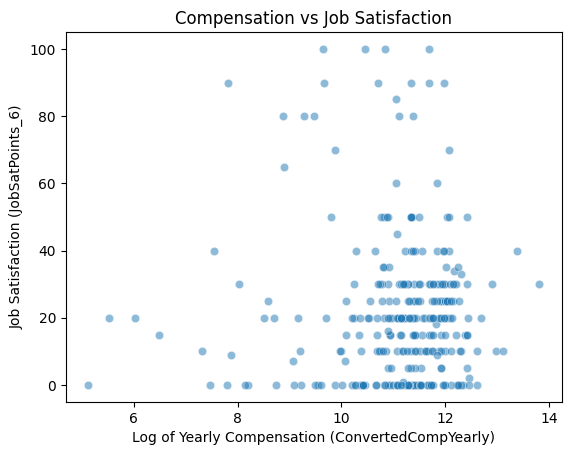

In [20]:
## Write your code here
# Select relevant columns and drop missing values
clean_df = df[['ConvertedCompYearly', 'JobSatPoints_6']].dropna().head(300)

# Optional: log-transform compensation to handle skewness
clean_df['LogComp'] = np.log1p(clean_df['ConvertedCompYearly'])

# Scatter plot
sns.scatterplot(
    x='LogComp',
    y='JobSatPoints_6',
    data=clean_df,
    alpha=0.5
)

plt.xlabel('Log of Yearly Compensation (ConvertedCompYearly)')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')
plt.title('Compensation vs Job Satisfaction')
plt.show()
##Among the top 300 respondents, job satisfaction shows high variability across compensation levels,
##indicating that higher pay does not necessarily lead to higher job satisfaction.

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


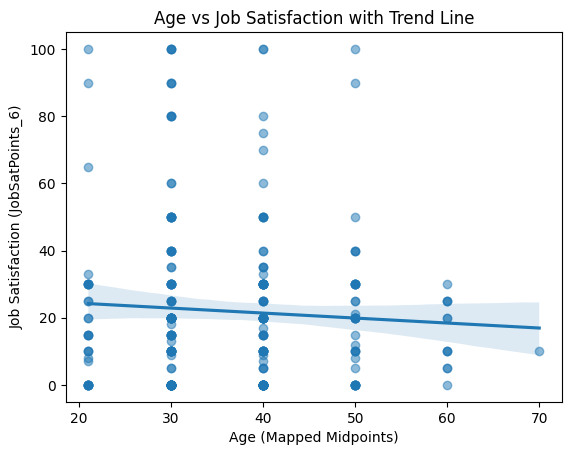

In [21]:
## Write your code here
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df['Age_mapped'] = df['Age'].map(age_map)

clean_df = df[['Age_mapped', 'JobSatPoints_6']].dropna().head(300)

sns.regplot(
    x='Age_mapped',
    y='JobSatPoints_6',
    data=clean_df,
    scatter_kws={'alpha': 0.5}
)

plt.xlabel('Age (Mapped Midpoints)')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')
plt.title('Age vs Job Satisfaction with Trend Line')
plt.show()
##The scatter plot indicates a weak negative relationship between age and job satisfaction,
##with high variability across all age groups, suggesting that age alone does not strongly influence job satisfaction

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


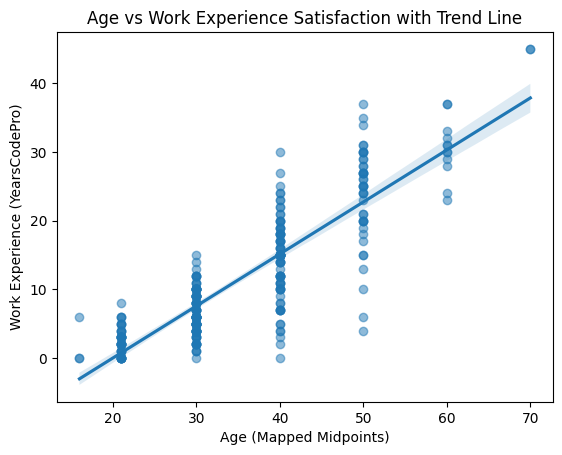

In [24]:
## Write your code here
## Write your code here
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df['Age_mapped'] = df['Age'].map(age_map)

df["YearsCodePro"] = df["YearsCodePro"].replace({
    "Less than 1 year": "0",
    "More than 50 years": "50"
})

# Convert to numeric
df["YearsCodePro_Num"] = pd.to_numeric(df["YearsCodePro"], errors="coerce")

clean_df = df[['Age_mapped', 'YearsCodePro_Num']].dropna().head(300)
 
sns.regplot(
    x='Age_mapped',
    y='YearsCodePro_Num',
    data=clean_df,
    scatter_kws={'alpha': 0.5}
)

plt.xlabel('Age (Mapped Midpoints)')
plt.ylabel('Work Experience (YearsCodePro)')
plt.title('Age vs Work Experience Satisfaction with Trend Line')
plt.show()
##The scatter plot reveals a strong positive relationship between age and work experience, with experience generally increasing as age increases,
##though with notable variation across individuals.

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


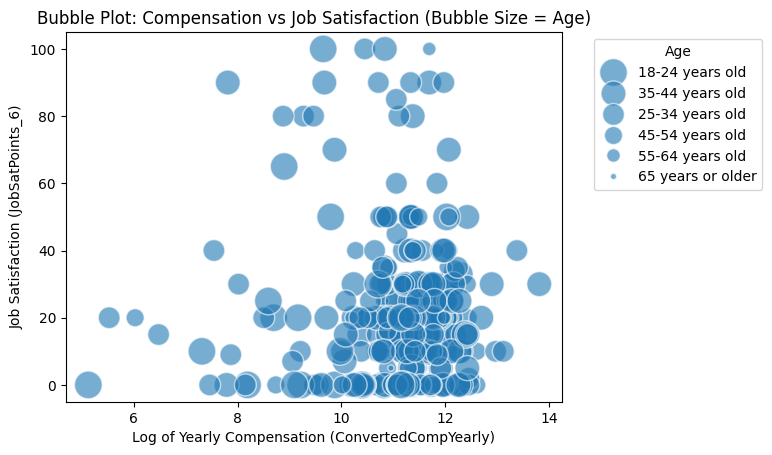

In [26]:
## Write your code here

# Select relevant columns and drop missing values
clean_df = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Age']].dropna().head(300)

# Log-transform compensation to handle skewness
clean_df['LogComp'] = np.log1p(clean_df['ConvertedCompYearly'])

# Bubble plot
sns.scatterplot(
    x='LogComp',
    y='JobSatPoints_6',
    size='Age',
    data=clean_df,
    alpha=0.6,
    sizes=(20, 400)
)

plt.xlabel('Log of Yearly Compensation (ConvertedCompYearly)')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')
plt.title('Bubble Plot: Compensation vs Job Satisfaction (Bubble Size = Age)')
plt.legend(title='Age', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##Among the top 300 respondents, job satisfaction varies widely across compensation levels and age groups, 
##indicating that neither compensation nor age strongly predicts job satisfaction.

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


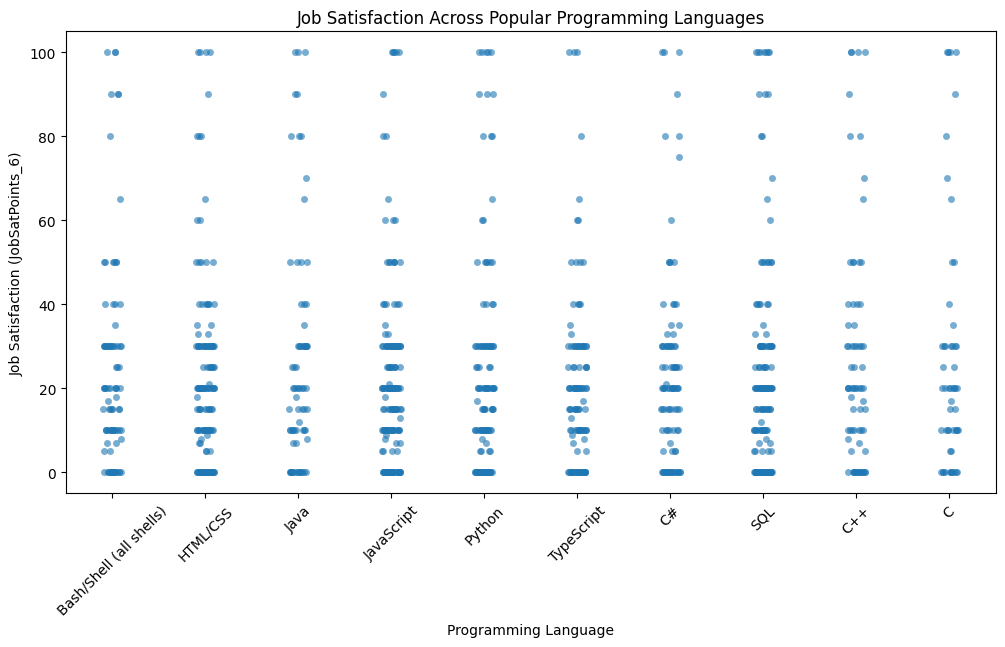

In [28]:
# Keep required columns and drop missing values
lang_df = df[['LanguageHaveWorkedWith', 'JobSatPoints_6']].dropna().head(300)

# Split multiple languages into separate rows
lang_df = lang_df.assign(
    LanguageHaveWorkedWith=lang_df['LanguageHaveWorkedWith'].str.split(';')
).explode('LanguageHaveWorkedWith')

top_languages = (
    lang_df['LanguageHaveWorkedWith']
    .value_counts()
    .head(10)
    .index
)

lang_df_top = lang_df[
    lang_df['LanguageHaveWorkedWith'].isin(top_languages)
]

plt.figure(figsize=(12, 6))

sns.stripplot(
    x='LanguageHaveWorkedWith',
    y='JobSatPoints_6',
    data=lang_df_top,
    jitter=True,
    alpha=0.6
)

plt.xlabel('Programming Language')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')
plt.title('Job Satisfaction Across Popular Programming Languages')
plt.xticks(rotation=45)
plt.show()
##Among the top 300 respondents, job satisfaction varies widely across all popular programming languages, 
##indicating that no single language is strongly associated with higher satisfaction.

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


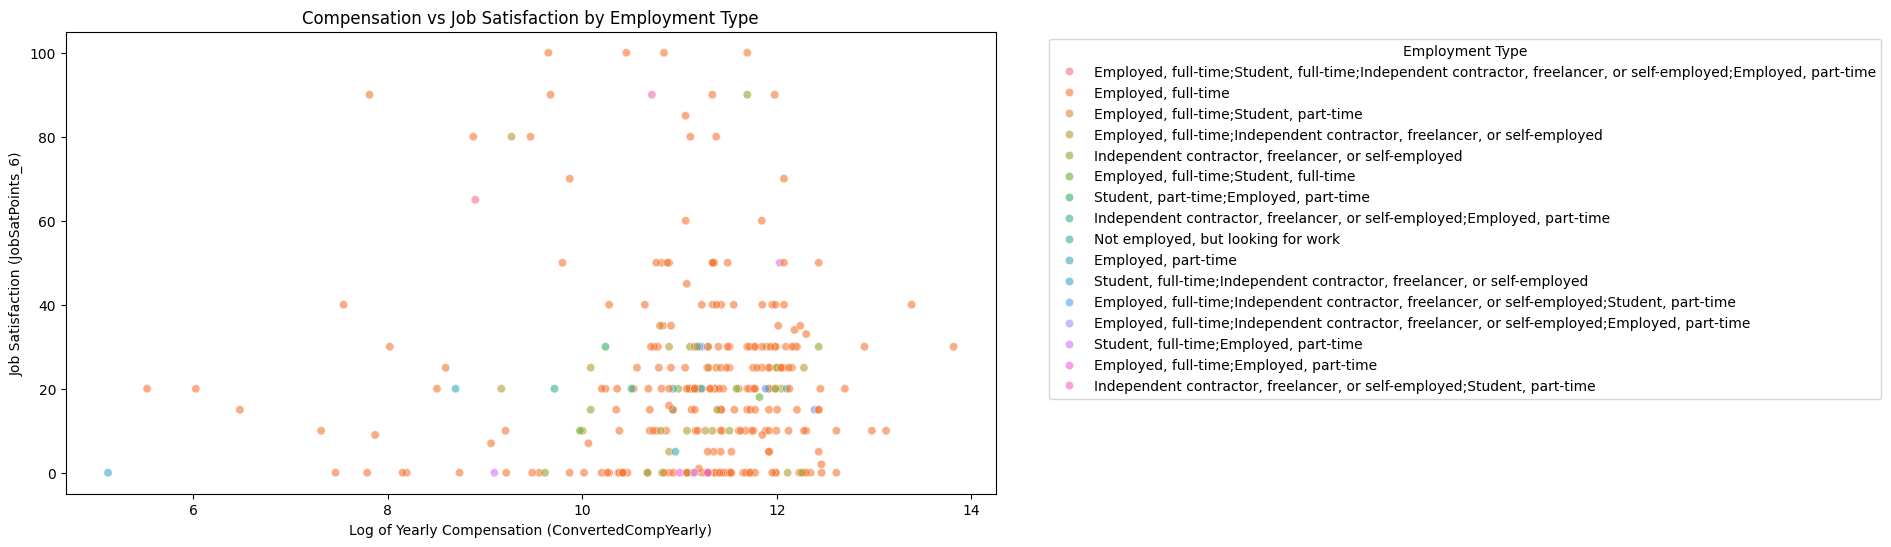

In [30]:
## Write your code here
# Select relevant columns and drop missing values
clean_df = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Employment']].dropna().head(300)

# Log-transform compensation to handle skewness
clean_df['LogComp'] = np.log1p(clean_df['ConvertedCompYearly'])

# Scatter plot with color coding by employment type
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x='LogComp',
    y='JobSatPoints_6',
    hue='Employment',
    data=clean_df,
    alpha=0.6
)

plt.xlabel('Log of Yearly Compensation (ConvertedCompYearly)')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')
plt.title('Compensation vs Job Satisfaction by Employment Type')
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
##Job satisfaction varies widely across compensation levels and employment types,
##indicating that neither pay nor employment status alone strongly predicts job satisfaction.

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


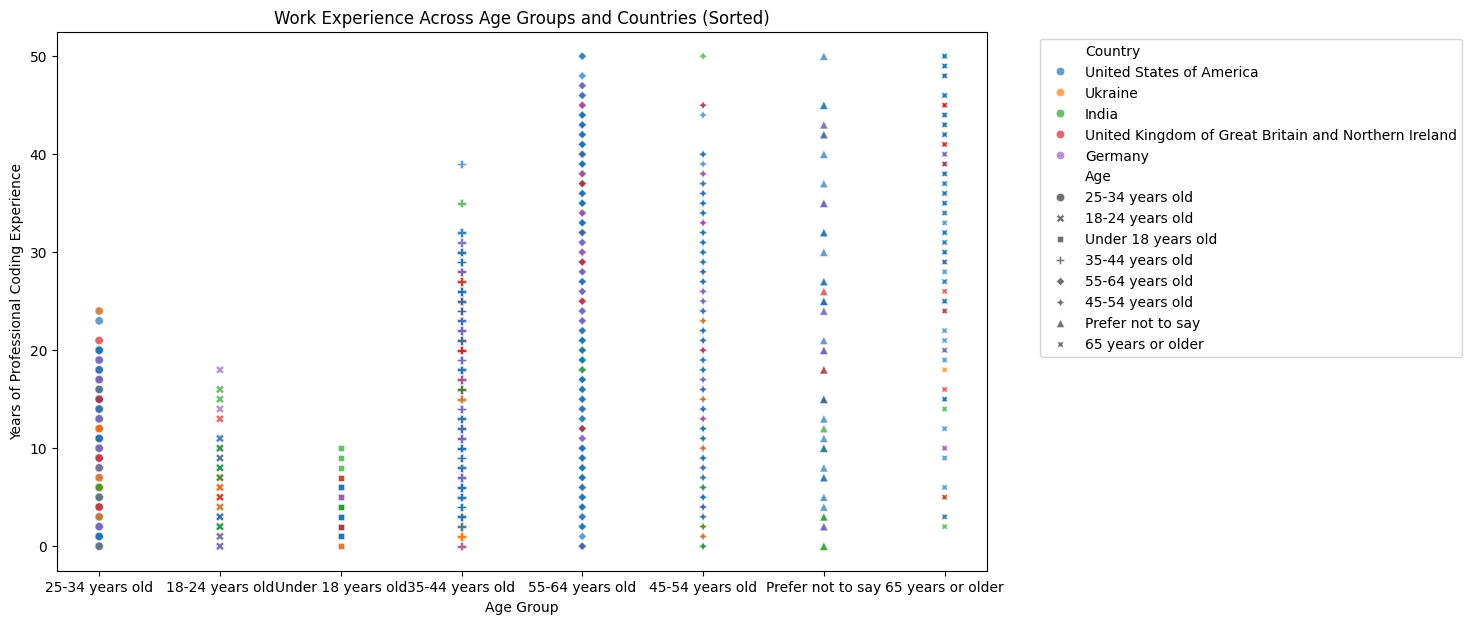

In [35]:
## Write your code here
# Convert YearsCodePro to numeric
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
clean_df = df[['Age', 'YearsCodePro', 'Country']].dropna()

# Sort by YearsCodePro
clean_df = clean_df.sort_values(by='YearsCodePro')

##Limit to Top Countries
top_countries = clean_df['Country'].value_counts().head(5).index
clean_df = clean_df[clean_df['Country'].isin(top_countries)]

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=clean_df,
    x='Age',
    y='YearsCodePro',
    hue='Country',
    style='Age',
    alpha=0.7
)

plt.xlabel('Age Group')
plt.ylabel('Years of Professional Coding Experience')
plt.title('Work Experience Across Age Groups and Countries (Sorted)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
##Work experience increases with age across all countries, though noticeable variation within age groups suggests that 
##country-specific factors also influence professional experience levels.

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
